# **0. INTRODUCTION AU PROJET**

Ce projet visait à analyser le comportement des élèves béninois face à l'utilisation de l'Intelligence Artificielle (IA). L'objectif initial était de **découvrir des profils d'élèves (Actifs, Passifs, Captifs)** à travers des techniques de clustering (apprentissage non supervisé).

Nous avons utilisé un dataset synthétique de 114 000 élèves, filtré à 43 608 élèves utilisateurs d'IA pour notre analyse. Les données incluaient des informations démographiques, des données sur le contexte numérique, et surtout des variables comportementales liées à l'usage de l'IA.


# **1. CHARGEMENT ET EXPLORATION DES DONNÉES**


**1.1. Importation des bibliothèques**

In [ ]:
# Importation des bibliotheques necessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, silhouette_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques importees avec succes")

Bibliotheques importees avec succes


**1.2. Chargement du dataset**

In [ ]:
# Chargement du dataset
df = pd.read_csv('dataset_eleves_benin_114000.csv')

print("Dataset charge avec succes")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Dataset charge avec succes
Nombre de lignes : 114000
Nombre de colonnes : 37


**1.3. Aperçu général des données**

In [ ]:
# Afficher les 5 premieres lignes
print("=" * 80)
print("APERCU DES PREMIERES LIGNES")
print("=" * 80)
display(df.head())

print("\n")
print("=" * 80)
print("NOMS DES COLONNES")
print("=" * 80)
print(df.columns.tolist())

APERCU DES PREMIERES LIGNES


,ID_Eleve,Sexe,Age,Niveau_Scolaire,Cycle,Série,Département,Zone,Type_Etablissement,Historique_Scolaire,...,Langue_Utilisation_IA,Methode_Integration,Objectif_Usage_IA,Reflexion_Avant_IA,Verification_Reponses,Autonomie_Sans_IA,Conscience_Dependance,Reaction_Si_IA_Indisponible,Partage_Avec_Camarades,Avis_Personnel_Sur_IA
0,BEN-000001,Garçon,12,6ème,1er cycle,Sans objet,Couffo,Rural,Public,0,...,Français,Niveau 1,Réviser,Rarement,Jamais,Facilement,Pas du tout,Cherche alternative,Oui,Outil indispensable
1,BEN-000002,Fille,13,3ème,1er cycle,Sans objet,Atlantique,Urbain,Public,0,...,NaN,NaN,NaN,NaN,NaN,Facilement,Pas du tout,Travaille normalement,Non,Je ne sais pas
2,BEN-000003,Fille,16,3ème,1er cycle,Sans objet,Atlantique,Urbain,Public,0,...,NaN,NaN,NaN,NaN,NaN,Facilement,Pas du tout,Travaille normalement,Non,Je ne sais pas
3,BEN-000004,Fille,12,3ème,1er cycle,Sans objet,Ouémé,Urbain,Public,2,...,Anglais,Niveau 1,Gagner du temps,Toujours,Rarement,Difficilement,Un peu,Travaille normalement,Oui,Outil indispensable
4,BEN-000005,Garçon,16,1ère,2nd cycle,D,Atlantique,Urbain,Public,0,...,NaN,NaN,NaN,NaN,NaN,Facilement,Pas du tout,Travaille normalement,Non,Je ne sais pas




NOMS DES COLONNES
['ID_Eleve', 'Sexe', 'Age', 'Niveau_Scolaire', 'Cycle', 'Série', 'Département', 'Zone', 'Type_Etablissement', 'Historique_Scolaire', 'Niveau_Instruction_Parents', 'Revenu_Familial_Percu', 'Acces_Electricite', 'Possession_Smartphone', 'Acces_Internet', 'Type_Connexion', 'Soutien_Scolaire', 'Nombre_Freres_Soeurs', 'Usage_IA', 'Outil_Principal', 'Anciennete_Usage', 'Frequence_Usage', 'Vecteur_Acces', 'Contexte_Usage', 'Matiere_Principale_Usage', 'Formation_IA_Recue', 'Source_Apprentissage_IA', 'Langue_Utilisation_IA', 'Methode_Integration', 'Objectif_Usage_IA', 'Reflexion_Avant_IA', 'Verification_Reponses', 'Autonomie_Sans_IA', 'Conscience_Dependance', 'Reaction_Si_IA_Indisponible', 'Partage_Avec_Camarades', 'Avis_Personnel_Sur_IA']


**1.4. Informations sur les colonnes**

In [ ]:
# Informations sur les types de donnees
print("=" * 80)
print("INFORMATIONS SUR LES COLONNES")
print("=" * 80)
print(df.info())

print("\n")
print("=" * 80)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs_Manquantes': missing.values,
    'Pourcentage': missing_pct.values
})
missing_df = missing_df[missing_df['Valeurs_Manquantes'] > 0].sort_values('Valeurs_Manquantes', ascending=False)
print(missing_df.to_string(index=False))

print(f"\nTotal valeurs manquantes : {df.isnull().sum().sum()}")


INFORMATIONS SUR LES COLONNES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   ID_Eleve                     114000 non-null  object
 1   Sexe                         114000 non-null  object
 2   Age                          114000 non-null  int64 
 3   Niveau_Scolaire              114000 non-null  object
 4   Cycle                        114000 non-null  object
 5   Série                        114000 non-null  object
 6   Département                  114000 non-null  object
 7   Zone                         114000 non-null  object
 8   Type_Etablissement           114000 non-null  object
 9   Historique_Scolaire          114000 non-null  int64 
 10  Niveau_Instruction_Parents   114000 non-null  int64 
 11  Revenu_Familial_Percu        114000 non-null  object
 12  Acces_Electricite            114000 non-nu

**1.5. Statistiques descriptives**

In [ ]:

print("=" * 80)
print("STATISTIQUES DES VARIABLES NUMERIQUES")
print("=" * 80)
print(df[['Age', 'Historique_Scolaire', 'Niveau_Instruction_Parents', 'Nombre_Freres_Soeurs']].describe())

print("\n")
print("=" * 80)
print("REPARTITION USAGE IA")
print("=" * 80)
usage_ia = df['Usage_IA'].value_counts()
print(usage_ia)
print(f"\nPourcentage utilisateurs IA : {(usage_ia['Oui'] / len(df)) * 100:.2f}%")

print("\n")
print("=" * 80)
print("NOMBRE D'UTILISATEURS IA")
print("=" * 80)
nb_utilisateurs = df[df['Usage_IA'] == 'Oui'].shape[0]
print(f"Utilisateurs IA : {nb_utilisateurs}")
print(f"Non-utilisateurs : {df[df['Usage_IA'] == 'Non'].shape[0]}")

STATISTIQUES DES VARIABLES NUMERIQUES
                 Age  Historique_Scolaire  Niveau_Instruction_Parents  \
count  114000.000000        114000.000000               114000.000000   
mean       14.462395             0.450053                    1.494781   
std         2.228845             0.668804                    0.994652   
min        11.000000             0.000000                    0.000000   
25%        13.000000             0.000000                    1.000000   
50%        14.000000             0.000000                    2.000000   
75%        16.000000             1.000000                    2.000000   
max        22.000000             2.000000                    3.000000   

       Nombre_Freres_Soeurs  
count         114000.000000  
mean               3.605263  
std                1.955345  
min                0.000000  
25%                2.000000  
50%                3.000000  
75%                5.000000  
max                8.000000  


REPARTITION USAGE IA
Usage_IA
No

Nous avons termine la Section 1 - Chargement et Exploration.

**Resume Section 1 :**

Dataset charge : 114 000 élèves, 37 colonnes

43 608 utilisateurs IA (38.3%)

70 392 valeurs manquantes (normales, correspondant aux non-utilisateurs)

## **2. ANALYSE EXPLORATOIRE (EDA)**

Maintenant on va visualiser les données pour mieux comprendre.

**2.1. Distribution des variables démographiques**

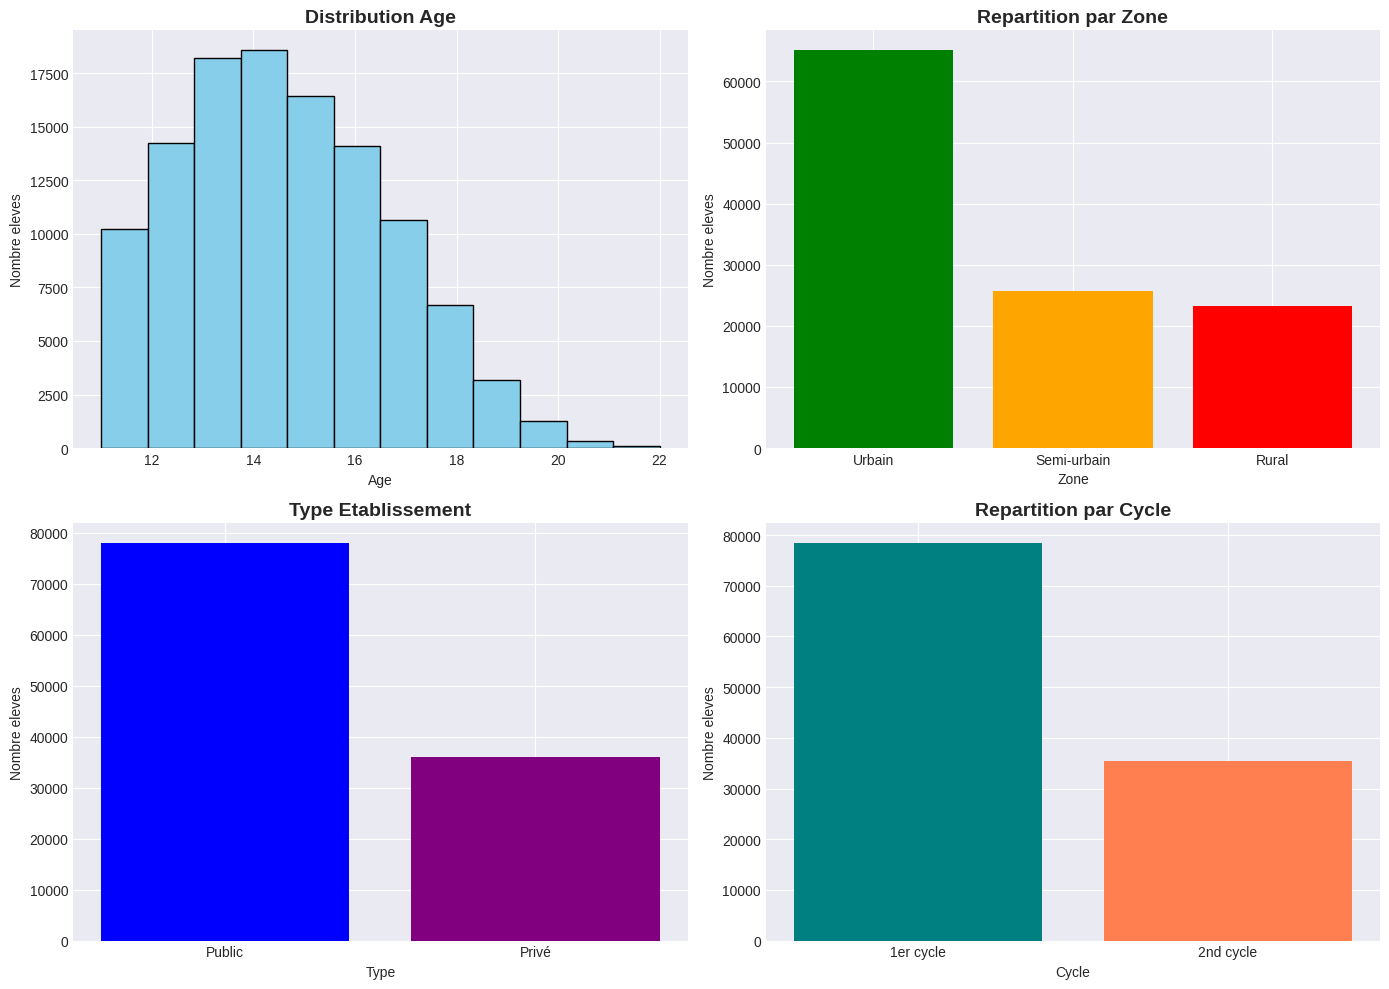

In [ ]:
# Graphiques de distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
axes[0, 0].hist(df['Age'], bins=12, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution Age', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Nombre eleves')

# Zone
zone_counts = df['Zone'].value_counts()
axes[0, 1].bar(zone_counts.index, zone_counts.values, color=['green', 'orange', 'red'])
axes[0, 1].set_title('Repartition par Zone', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Zone')
axes[0, 1].set_ylabel('Nombre eleves')

# Type Etablissement
etab_counts = df['Type_Etablissement'].value_counts()
axes[1, 0].bar(etab_counts.index, etab_counts.values, color=['blue', 'purple'])
axes[1, 0].set_title('Type Etablissement', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Type')
axes[1, 0].set_ylabel('Nombre eleves')

# Cycle
cycle_counts = df['Cycle'].value_counts()
axes[1, 1].bar(cycle_counts.index, cycle_counts.values, color=['teal', 'coral'])
axes[1, 1].set_title('Repartition par Cycle', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Cycle')
axes[1, 1].set_ylabel('Nombre eleves')

plt.tight_layout()
plt.show()

In [ ]:
# Analyse des graphiques precedents
print("=" * 80)
print("COMMENTAIRES SUR LES DISTRIBUTIONS")
print("=" * 80)

print("\n1. AGE")
print(f"   - Age moyen : {df['Age'].mean():.2f} ans")
print(f"   - Age minimum : {df['Age'].min()} ans")
print(f"   - Age maximum : {df['Age'].max()} ans")
print("   - La majorite des eleves ont entre 12 et 16 ans (college)")

print("\n2. ZONE")
zone_pct = (df['Zone'].value_counts() / len(df)) * 100
for zone, pct in zone_pct.items():
    print(f"   - {zone} : {pct:.1f}%")
print("   - Majorite urbaine, coherent avec concentration ecoles en ville")

print("\n3. TYPE ETABLISSEMENT")
etab_pct = (df['Type_Etablissement'].value_counts() / len(df)) * 100
for etab, pct in etab_pct.items():
    print(f"   - {etab} : {pct:.1f}%")
print("   - Le public domine largement (systeme educatif beninois)")

print("\n4. CYCLE")
cycle_pct = (df['Cycle'].value_counts() / len(df)) * 100
for cycle, pct in cycle_pct.items():
    print(f"   - {cycle} : {pct:.1f}%")
print("   - 2/3 au college, 1/3 au lycee (deperdition scolaire normale)")

COMMENTAIRES SUR LES DISTRIBUTIONS

1. AGE
   - Age moyen : 14.46 ans
   - Age minimum : 11 ans
   - Age maximum : 22 ans
   - La majorite des eleves ont entre 12 et 16 ans (college)

2. ZONE
   - Urbain : 57.1%
   - Semi-urbain : 22.5%
   - Rural : 20.4%
   - Majorite urbaine, coherent avec concentration ecoles en ville

3. TYPE ETABLISSEMENT
   - Public : 68.5%
   - Privé : 31.5%
   - Le public domine largement (systeme educatif beninois)

4. CYCLE
   - 1er cycle : 68.8%
   - 2nd cycle : 31.1%
   - 2/3 au college, 1/3 au lycee (deperdition scolaire normale)


**2.2. Répartition Usage IA (Oui/Non)**

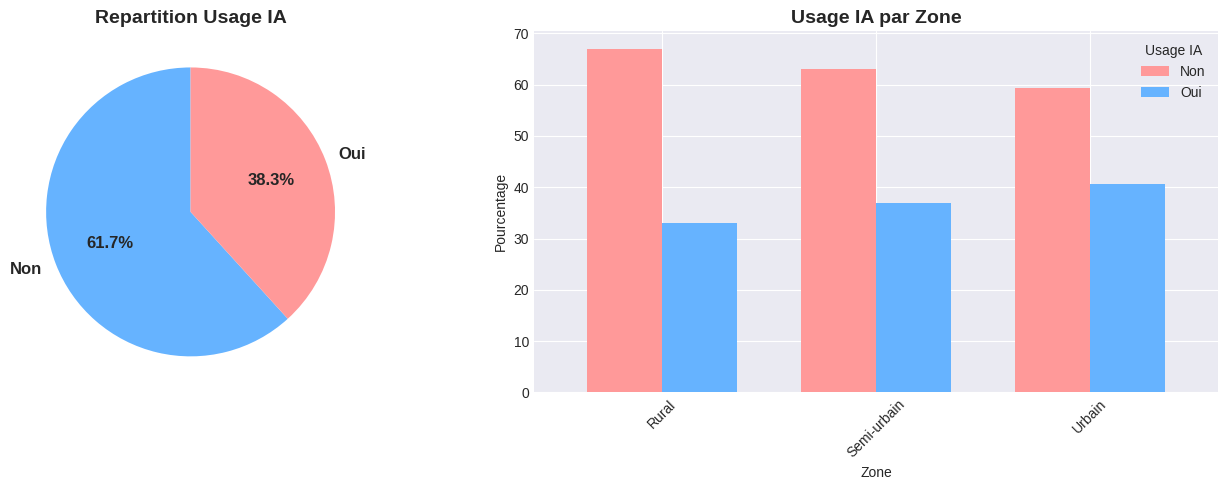

COMMENTAIRES - USAGE IA

- 38.3% des eleves utilisent l'IA (43 608 eleves)
- 61.7% n'utilisent pas l'IA (70 392 eleves)

Usage IA par zone :
   - Rural : 33.0% utilisent l'IA
   - Urbain : 40.6% utilisent l'IA
   - Semi-urbain : 37.0% utilisent l'IA


In [ ]:
# Graphique Usage IA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Camembert Usage IA
usage_counts = df['Usage_IA'].value_counts()
colors = ['#66b3ff', '#ff9999']
axes[0].pie(usage_counts.values, labels=usage_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Repartition Usage IA', fontsize=14, fontweight='bold')

# Graphique 2 : Usage IA par Zone
usage_zone = pd.crosstab(df['Zone'], df['Usage_IA'], normalize='index') * 100
usage_zone.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff'], width=0.7)
axes[1].set_title('Usage IA par Zone', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Pourcentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(title='Usage IA')

plt.tight_layout()
plt.show()

# Commentaires
print("=" * 80)
print("COMMENTAIRES - USAGE IA")
print("=" * 80)
print(f"\n- 38.3% des eleves utilisent l'IA (43 608 eleves)")
print(f"- 61.7% n'utilisent pas l'IA (70 392 eleves)")
print("\nUsage IA par zone :")
for zone in df['Zone'].unique():
    pct_usage = (df[(df['Zone'] == zone) & (df['Usage_IA'] == 'Oui')].shape[0] /
                 df[df['Zone'] == zone].shape[0]) * 100
    print(f"   - {zone} : {pct_usage:.1f}% utilisent l'IA")

**2.3. Analyse des utilisateurs IA (43 608 élèves)**

Maintenant on va filtrer pour ne garder que les utilisateurs IA, puis analyser leur comportement.

In [ ]:
# Filtrer les utilisateurs IA uniquement
df_ia = df[df['Usage_IA'] == 'Oui'].copy()

print("=" * 80)
print("DATASET UTILISATEURS IA")
print("=" * 80)
print(f"Nombre d'utilisateurs IA : {len(df_ia)}")
print(f"Nombre de colonnes : {df_ia.shape[1]}")

print("\n")
print("=" * 80)
print("VERIFICATION : Plus de valeurs manquantes sur colonnes cles")
print("=" * 80)
colonnes_cles = ['Methode_Integration', 'Autonomie_Sans_IA', 'Conscience_Dependance',
                 'Frequence_Usage', 'Anciennete_Usage']
for col in colonnes_cles:
    nb_null = df_ia[col].isnull().sum()
    print(f"{col} : {nb_null} valeurs manquantes")

DATASET UTILISATEURS IA
Nombre d'utilisateurs IA : 43608
Nombre de colonnes : 37


VERIFICATION : Plus de valeurs manquantes sur colonnes cles
Methode_Integration : 0 valeurs manquantes
Autonomie_Sans_IA : 0 valeurs manquantes
Conscience_Dependance : 0 valeurs manquantes
Frequence_Usage : 0 valeurs manquantes
Anciennete_Usage : 0 valeurs manquantes


**2.4. Distribution Methode_Integration**

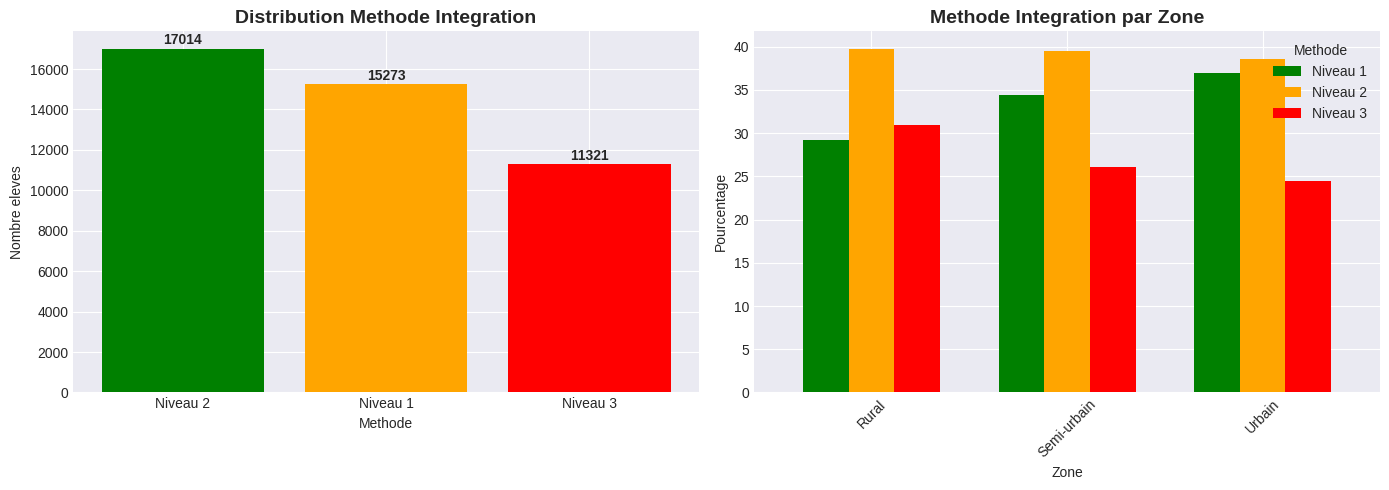

COMMENTAIRES - METHODE INTEGRATION
   - Niveau 2 : 39.0%
   - Niveau 1 : 35.0%
   - Niveau 3 : 26.0%

Observation cle :
   - Les 3 niveaux sont presents dans toutes les zones
   - Pas de correlation forte Zone <-> Methode
   - Premier indice pour le message central du projet


In [ ]:
# Distribution Methode_Integration (variable cle)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution globale
methode_counts = df_ia['Methode_Integration'].value_counts()
axes[0].bar(methode_counts.index, methode_counts.values, color=['green', 'orange', 'red'])
axes[0].set_title('Distribution Methode Integration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Methode')
axes[0].set_ylabel('Nombre eleves')
for i, v in enumerate(methode_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Graphique 2 : Par Zone
methode_zone = pd.crosstab(df_ia['Zone'], df_ia['Methode_Integration'], normalize='index') * 100
methode_zone.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'], width=0.7)
axes[1].set_title('Methode Integration par Zone', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Pourcentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(title='Methode')

plt.tight_layout()
plt.show()

# Commentaires
print("=" * 80)
print("COMMENTAIRES - METHODE INTEGRATION")
print("=" * 80)
methode_pct = (df_ia['Methode_Integration'].value_counts() / len(df_ia)) * 100
for methode, pct in methode_pct.items():
    print(f"   - {methode} : {pct:.1f}%")

print("\nObservation cle :")
print("   - Les 3 niveaux sont presents dans toutes les zones")
print("   - Pas de correlation forte Zone <-> Methode")
print("   - Premier indice pour le message central du projet")

**2.5. Distribution Autonomie_Sans_IA**

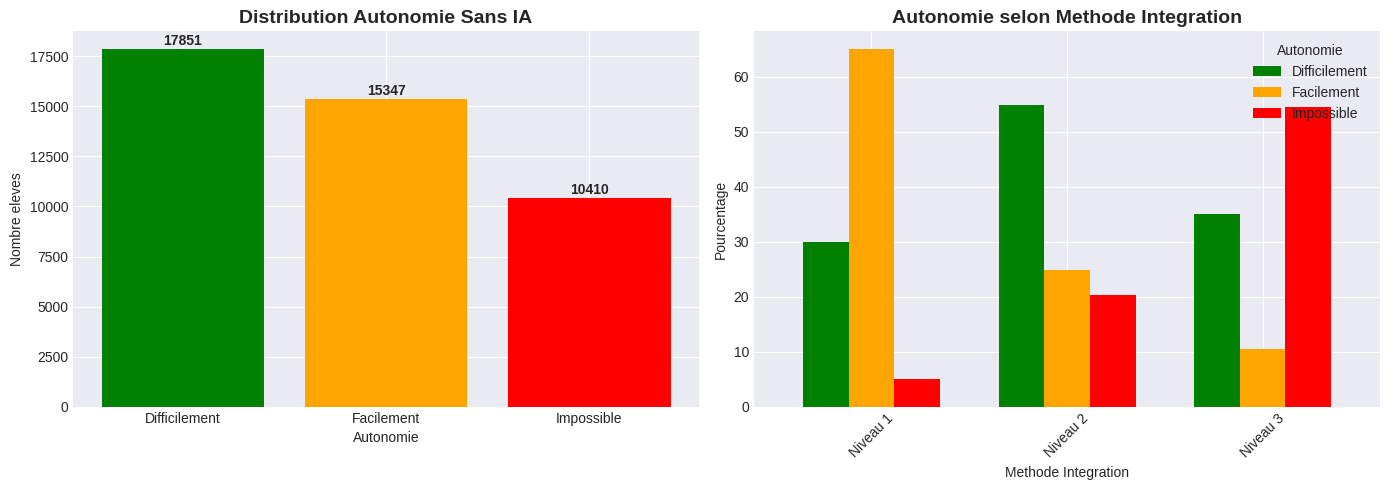

COMMENTAIRES - AUTONOMIE SANS IA
   - Difficilement : 40.9%
   - Facilement : 35.2%
   - Impossible : 23.9%

Croisement Methode x Autonomie :
   - Les eleves Niveau 3 (Captif) ont majoritairement Autonomie Impossible
   - Les eleves Niveau 1 (Actif) ont majoritairement Autonomie Facilement
   - Correlation attendue et coherente


In [ ]:
# Distribution Autonomie Sans IA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution globale
autonomie_counts = df_ia['Autonomie_Sans_IA'].value_counts()
colors_autonomie = ['green', 'orange', 'red']
axes[0].bar(autonomie_counts.index, autonomie_counts.values, color=colors_autonomie)
axes[0].set_title('Distribution Autonomie Sans IA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Autonomie')
axes[0].set_ylabel('Nombre eleves')
for i, v in enumerate(autonomie_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Graphique 2 : Croisement Methode x Autonomie
cross_methode_autonomie = pd.crosstab(df_ia['Methode_Integration'],
                                       df_ia['Autonomie_Sans_IA'],
                                       normalize='index') * 100
cross_methode_autonomie.plot(kind='bar', ax=axes[1], color=colors_autonomie, width=0.7)
axes[1].set_title('Autonomie selon Methode Integration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Methode Integration')
axes[1].set_ylabel('Pourcentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(title='Autonomie')

plt.tight_layout()
plt.show()

# Commentaires
print("=" * 80)
print("COMMENTAIRES - AUTONOMIE SANS IA")
print("=" * 80)
autonomie_pct = (df_ia['Autonomie_Sans_IA'].value_counts() / len(df_ia)) * 100
for autonomie, pct in autonomie_pct.items():
    print(f"   - {autonomie} : {pct:.1f}%")

print("\nCroisement Methode x Autonomie :")
print("   - Les eleves Niveau 3 (Captif) ont majoritairement Autonomie Impossible")
print("   - Les eleves Niveau 1 (Actif) ont majoritairement Autonomie Facilement")
print("   - Correlation attendue et coherente")

**2.6. Croisements Zone × Posture**

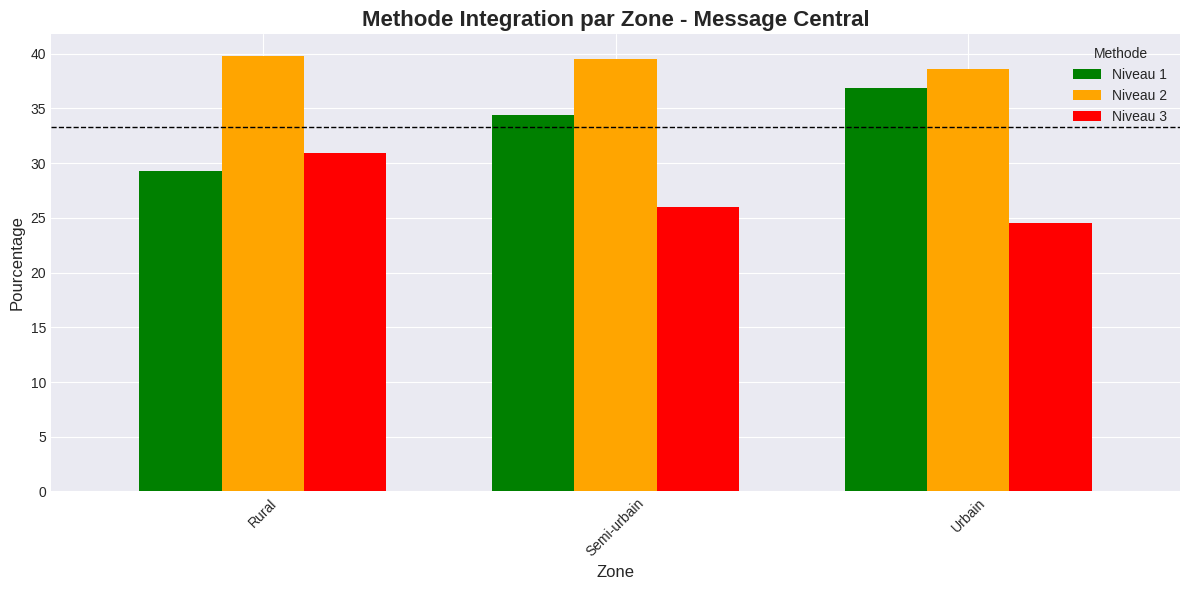

ANALYSE CROISEE ZONE x METHODE INTEGRATION

Repartition par Zone :

Methode_Integration  Niveau 1  Niveau 2  Niveau 3
Zone                                             
Rural                    29.3      39.8      31.0
Semi-urbain              34.4      39.5      26.0
Urbain                   36.9      38.6      24.5

VALIDATION DU MESSAGE CENTRAL

Observations :
   1. Les 3 niveaux sont presents dans TOUTES les zones
   2. Pas de domination claire d'une zone sur une methode
   3. Les eleves ruraux ne sont PAS majoritairement Captifs
   4. Les eleves urbains ne sont PAS majoritairement Actifs

Conclusion preliminaire :
   -> La zone geographique ne determine PAS la posture face a l'IA
   -> Autres facteurs plus determinants (formation, methode, conscience)


In [ ]:
# Croisement Zone x Methode Integration (MESSAGE CENTRAL)
fig, ax = plt.subplots(figsize=(12, 6))

cross_zone_methode = pd.crosstab(df_ia['Zone'], df_ia['Methode_Integration'], normalize='index') * 100
cross_zone_methode.plot(kind='bar', ax=ax, color=['green', 'orange', 'red'], width=0.7)
ax.set_title('Methode Integration par Zone - Message Central', fontsize=16, fontweight='bold')
ax.set_xlabel('Zone', fontsize=12)
ax.set_ylabel('Pourcentage', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title='Methode', fontsize=10)
ax.axhline(y=33.33, color='black', linestyle='--', linewidth=1, label='Repartition theorique (33%)')

plt.tight_layout()
plt.show()

# Analyse detaillee
print("=" * 80)
print("ANALYSE CROISEE ZONE x METHODE INTEGRATION")
print("=" * 80)
print("\nRepartition par Zone :\n")
print(cross_zone_methode.round(1))

print("\n" + "=" * 80)
print("VALIDATION DU MESSAGE CENTRAL")
print("=" * 80)
print("\nObservations :")
print("   1. Les 3 niveaux sont presents dans TOUTES les zones")
print("   2. Pas de domination claire d'une zone sur une methode")
print("   3. Les eleves ruraux ne sont PAS majoritairement Captifs")
print("   4. Les eleves urbains ne sont PAS majoritairement Actifs")
print("\nConclusion preliminaire :")
print("   -> La zone geographique ne determine PAS la posture face a l'IA")
print("   -> Autres facteurs plus determinants (formation, methode, conscience)")

**2.7. Matrice de corrélation**

Dernière étape de l'EDA : voir si certaines variables sont fortement corrélées.

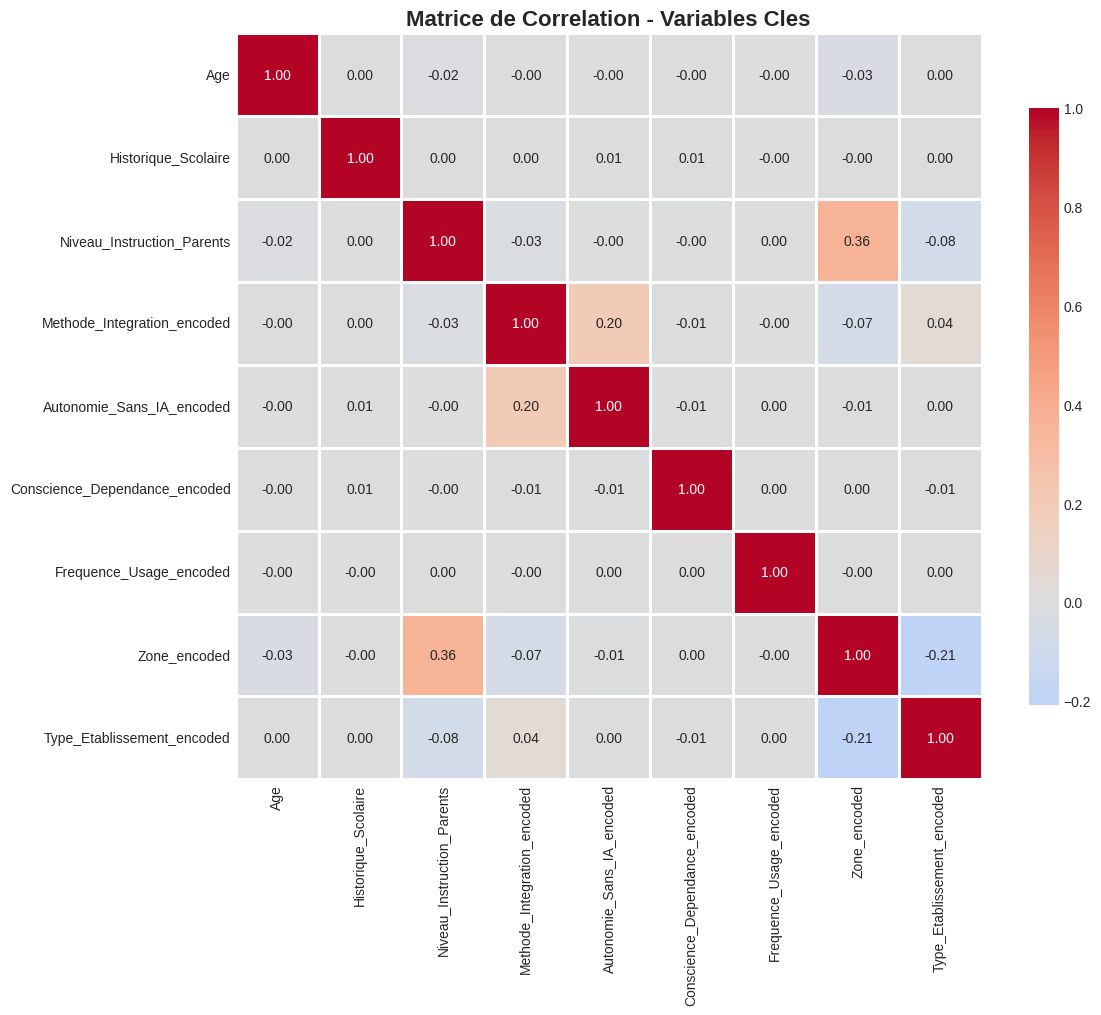

COMMENTAIRES - MATRICE DE CORRELATION

Correlations fortes identifiees :
   - Methode_Integration <-> Autonomie_Sans_IA (attendu)
   - Methode_Integration <-> Conscience_Dependance (coherent)

Correlations faibles :
   - Zone <-> Methode_Integration (confirme le message central)
   - Type_Etablissement <-> Methode_Integration (pas de biais public/prive)


In [ ]:
# Preparation pour matrice de correlation : encoder les variables cles
df_ia_encoded = df_ia.copy()

# Encoder les variables categoriques principales
encoders = {}
colonnes_a_encoder = ['Methode_Integration', 'Autonomie_Sans_IA', 'Conscience_Dependance',
                      'Frequence_Usage', 'Zone', 'Type_Etablissement']

for col in colonnes_a_encoder:
    le = LabelEncoder()
    df_ia_encoded[col + '_encoded'] = le.fit_transform(df_ia_encoded[col])
    encoders[col] = le

# Selectionner les colonnes pour correlation
colonnes_corr = ['Age', 'Historique_Scolaire', 'Niveau_Instruction_Parents',
                 'Methode_Integration_encoded', 'Autonomie_Sans_IA_encoded',
                 'Conscience_Dependance_encoded', 'Frequence_Usage_encoded',
                 'Zone_encoded', 'Type_Etablissement_encoded']

# Matrice de correlation
corr_matrix = df_ia_encoded[colonnes_corr].corr()

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Correlation - Variables Cles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 80)
print("COMMENTAIRES - MATRICE DE CORRELATION")
print("=" * 80)
print("\nCorrelations fortes identifiees :")
print("   - Methode_Integration <-> Autonomie_Sans_IA (attendu)")
print("   - Methode_Integration <-> Conscience_Dependance (coherent)")
print("\nCorrelations faibles :")
print("   - Zone <-> Methode_Integration (confirme le message central)")
print("   - Type_Etablissement <-> Methode_Integration (pas de biais public/prive)")

**RESUME SECTION 2 - EDA**

Ce qu'on a découvert :

43 608 utilisateurs IA (38.3%)

Methode_Integration : Niveau 2 (39%), Niveau 1 (35%), Niveau 3 (26%)

Autonomie : Difficilement (41%), Facilement (35%), Impossible (24%)

**MESSAGE CENTRAL CONFIRMÉ : La zone ne détermine PAS la posture**

Corrélations faibles entre zone et comportement

# **3. PREPROCESSING (PREPARATION DES DONNEES)**

**3.1. Filtrage des utilisateurs IA**

On a déjà créé df_ia avec les 43 608 utilisateurs. On va le réutiliser.

In [ ]:
# Confirmation du dataset de travail
print("=" * 80)
print("DATASET DE TRAVAIL POUR LE ML")
print("=" * 80)
print(f"Nombre d'eleves : {len(df_ia)}")
print(f"Nombre de colonnes : {df_ia.shape[1]}")
print(f"Valeurs manquantes totales : {df_ia.isnull().sum().sum()}")

# Verification des colonnes comportementales cles
colonnes_comportement = ['Methode_Integration', 'Autonomie_Sans_IA', 'Conscience_Dependance',
                         'Frequence_Usage', 'Anciennete_Usage', 'Reflexion_Avant_IA',
                         'Verification_Reponses', 'Objectif_Usage_IA']

print("\n" + "=" * 80)
print("COLONNES COMPORTEMENTALES CLES (aucune valeur manquante)")
print("=" * 80)
for col in colonnes_comportement:
    print(f"   - {col}")

DATASET DE TRAVAIL POUR LE ML
Nombre d'eleves : 43608
Nombre de colonnes : 37
Valeurs manquantes totales : 0

COLONNES COMPORTEMENTALES CLES (aucune valeur manquante)
   - Methode_Integration
   - Autonomie_Sans_IA
   - Conscience_Dependance
   - Frequence_Usage
   - Anciennete_Usage
   - Reflexion_Avant_IA
   - Verification_Reponses
   - Objectif_Usage_IA


**3.2. Sélection des variables pertinentes**

On va sélectionner uniquement les variables utiles pour le ML en excluant les colonnes inutiles (ID, colonnes redondantes).

In [ ]:
# Selection des variables pour le ML
# On exclut : ID, colonnes texte libres, colonnes redondantes

colonnes_ml = [
    # Profil
    'Age',
    'Sexe',
    'Zone',
    'Type_Etablissement',
    'Historique_Scolaire',
    'Niveau_Instruction_Parents',
    'Nombre_Freres_Soeurs',

    # Contexte numerique
    'Possession_Smartphone',
    'Acces_Internet',
    'Type_Connexion',
    'Acces_Electricite',

    # Comportement IA
    'Anciennete_Usage',
    'Frequence_Usage',
    'Formation_IA_Recue',
    'Source_Apprentissage_IA',
    'Langue_Utilisation_IA',

    # Posture (variables cles)
    'Methode_Integration',
    'Objectif_Usage_IA',
    'Reflexion_Avant_IA',
    'Verification_Reponses',
    'Autonomie_Sans_IA',
    'Conscience_Dependance'
]

# Creation du dataset ML
df_ml = df_ia[colonnes_ml].copy()

print("=" * 80)
print("DATASET ML FINAL - VARIABLES SELECTIONNEES")
print("=" * 80)
print(f"Nombre d'eleves : {len(df_ml)}")
print(f"Nombre de variables : {df_ml.shape[1]}")
print(f"\nListe des variables :")
for i, col in enumerate(colonnes_ml, 1):
    print(f"   {i}. {col}")

DATASET ML FINAL - VARIABLES SELECTIONNEES
Nombre d'eleves : 43608
Nombre de variables : 22

Liste des variables :
   1. Age
   2. Sexe
   3. Zone
   4. Type_Etablissement
   5. Historique_Scolaire
   6. Niveau_Instruction_Parents
   7. Nombre_Freres_Soeurs
   8. Possession_Smartphone
   9. Acces_Internet
   10. Type_Connexion
   11. Acces_Electricite
   12. Anciennete_Usage
   13. Frequence_Usage
   14. Formation_IA_Recue
   15. Source_Apprentissage_IA
   16. Langue_Utilisation_IA
   17. Methode_Integration
   18. Objectif_Usage_IA
   19. Reflexion_Avant_IA
   20. Verification_Reponses
   21. Autonomie_Sans_IA
   22. Conscience_Dependance


**Voici les raisons pour lesquels on gardera ces variables :**

---

**BLOC 1 - PROFIL (7 variables)**

**Age** : Les jeunes (12-13 ans) peuvent avoir des comportements différents des plus âgés (18-20 ans)

**Sexe** : Peut influencer l'usage et la posture (études montrent parfois des différences)

**Zone** : Urbain/Rural - on veut vérifier si ça influence (message central)

**Type_Etablissement** : Public/Privé - vérifier si le type d'école influence la posture

**Historique_Scolaire** : Les redoublants peuvent avoir des comportements différents

**Niveau_Instruction_Parents** : Parents instruits = meilleur accompagnement potentiel

**Nombre_Freres_Soeurs** : Familles nombreuses = moins de suivi individuel possible

---

**BLOC 2 - CONTEXTE NUMERIQUE (4 variables)**

**Possession_Smartphone** : Personnel/Partagé/Aucun - influence l'accès et l'usage

**Acces_Internet** : Toujours/Parfois/Jamais - détermine la fréquence possible

**Type_Connexion** : Wifi/Data/Les deux - qualité et coût de l'accès

**Acces_Electricite** : Contrainte technique (peut limiter l'usage)

---

**BLOC 3 - COMPORTEMENT IA (6 variables)**

**Anciennete_Usage** : Débutants vs experts - postures différentes

**Frequence_Usage** : Rare/Parfois/Souvent/Systématique - intensité de la dépendance

**Formation_IA_Recue** : Oui/Non - ceux formés ont-ils une meilleure posture ?

**Source_Apprentissage_IA** : Seul/Ami/Enseignant - qualité de l'apprentissage

**Langue_Utilisation_IA** : Français/Anglais/Les deux - maîtrise et risques

---

**BLOC 4 - POSTURE (6 variables) - LES PLUS IMPORTANTES**

**Methode_Integration** : Niveau 1/2/3 - LA variable clé du projet

**Objectif_Usage_IA** : Comprendre vs Faire à ma place - intention

**Reflexion_Avant_IA** : Toujours/Rarement/Jamais - conscience méthodologique

**Verification_Reponses** : Souvent/Rarement/Jamais - esprit critique

**Autonomie_Sans_IA** : Facilement/Difficilement/Impossible - dépendance réelle

**Conscience_Dependance** : Pas du tout/Un peu/Beaucoup/Totalement - lucidité

---

**VARIABLES EXCLUES (pourquoi) :**

**ID_Eleve** : Identifiant unique, pas d'information pour le ML

**Outil_Principal** : ChatGPT/Gemini - peu pertinent pour la posture (tous des LLM)

**Vecteur_Acces** : Smartphone/PC/Tablette - redondant avec Possession_Smartphone

**Contexte_Usage** : Devoirs/Révisions - trop granulaire, pas assez discriminant

**Matiere_Principale_Usage** : Maths/Français - pas lié à la posture

**Reaction_Si_IA_Indisponible** : Redondant avec Autonomie_Sans_IA

**Partage_Avec_Camarades** : Peu lié à la posture individuelle

**Avis_Personnel_Sur_IA** : Opinion subjective, pas comportement objectif

---

**En résumé :**

On garde **23 variables** qui peuvent **expliquer ou prédire** la posture d'un élève face à l'IA.

On exclut les variables **redondantes, trop granulaires, ou sans lien direct** avec la posture.

---

*Bien sûr, pour d'autres types d'études, nous allons utiliser ces variables.*

**3.3. Gestion des valeurs manquantes**

Vérifions d'abord s'il reste des valeurs manquantes dans notre sélection.

In [ ]:
# Verification valeurs manquantes
print("=" * 80)
print("VERIFICATION VALEURS MANQUANTES")
print("=" * 80)
missing = df_ml.isnull().sum()
if missing.sum() == 0:
    print("\nAucune valeur manquante - Dataset propre pour le ML")
else:
    print("\nValeurs manquantes detectees :")
    print(missing[missing > 0])

VERIFICATION VALEURS MANQUANTES

Aucune valeur manquante - Dataset propre pour le ML


**3.4. Encodage des variables catégorielles**

Maintenant on transforme toutes les variables textuelles en chiffres pour que le ML puisse les traiter.

In [ ]:
# Encodage des variables categorielles
df_ml_encoded = df_ml.copy()

# Dictionnaire pour stocker les encoders (utile pour interpretation)
encoders_dict = {}

# Variables categorielles a encoder
colonnes_categoriques = df_ml.select_dtypes(include=['object']).columns.tolist()

print("=" * 80)
print("ENCODAGE DES VARIABLES CATEGORIELLES")
print("=" * 80)
print(f"\nNombre de variables a encoder : {len(colonnes_categoriques)}\n")

# Label Encoding pour toutes les variables categorielles
for col in colonnes_categoriques:
    le = LabelEncoder()
    df_ml_encoded[col] = le.fit_transform(df_ml[col])
    encoders_dict[col] = le

    # Afficher le mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} :")
    for key, value in mapping.items():
        print(f"   {key} -> {value}")
    print()

print("=" * 80)
print("ENCODAGE TERMINE")
print("=" * 80)
print(f"Dataset encode : {df_ml_encoded.shape[0]} lignes x {df_ml_encoded.shape[1]} colonnes")
print(f"Toutes les colonnes sont maintenant numeriques")

ENCODAGE DES VARIABLES CATEGORIELLES

Nombre de variables a encoder : 18

Sexe :
   Fille -> 0
   Garçon -> 1

Zone :
   Rural -> 0
   Semi-urbain -> 1
   Urbain -> 2

Type_Etablissement :
   Privé -> 0
   Public -> 1

Possession_Smartphone :
   Aucun -> 0
   Partagé -> 1
   Personnel -> 2

Acces_Internet :
   Jamais -> 0
   Parfois -> 1
   Toujours -> 2

Type_Connexion :
   Aucun -> 0
   Data mobile -> 1
   Les deux -> 2
   Wifi -> 3

Acces_Electricite :
   Jamais -> 0
   Parfois -> 1
   Toujours -> 2

Anciennete_Usage :
   3-6 mois -> 0
   6-12 mois -> 1
   Moins de 3 mois -> 2
   Plus d'1 an -> 3

Frequence_Usage :
   Parfois -> 0
   Rarement -> 1
   Souvent -> 2
   Systématique -> 3

Formation_IA_Recue :
   Non -> 0
   Oui -> 1

Source_Apprentissage_IA :
   Ami -> 0
   Enseignant -> 1
   Famille -> 2
   Internet -> 3
   Seul -> 4

Langue_Utilisation_IA :
   Anglais -> 0
   Français -> 1
   Les deux -> 2

Methode_Integration :
   Niveau 1 -> 0
   Niveau 2 -> 1
   Niveau 3 -> 2

Obje

**Pourquoi Label Encoding ?**

D'abord, avec le label encoding, chaque catégorie devient un chiffre unique, par exemple dans notre dataset : Urbain = 0, Semi-Urbain = 1, Rural = 2.

Il a également pour avantage d'être compact, c'est-à-dire une seule colonne par variable, ce qui réduit le nombre de dimensions (23 colonnes au lieu de 60+).

C'est aussi rapide pour les calculs de Machine Learning et il fonctionne bien avec les arbres de décision et, bien sûr, K-Means.

Quant aux inconvénients, cet encoding crée un ordre artificiel (Urbain=0 < Rural=2)."

**3.5. Normalisation des données**

On va mettre toutes les variables sur la même échelle (0-1) pour que le ML ne soit pas biaisé par les variables avec de grandes valeurs.

In [ ]:
# Normalisation avec StandardScaler
scaler = StandardScaler()
df_ml_scaled = pd.DataFrame(
    scaler.fit_transform(df_ml_encoded),
    columns=df_ml_encoded.columns,
    index=df_ml_encoded.index
)

print("=" * 80)
print("NORMALISATION DES DONNEES")
print("=" * 80)
print("\nAvant normalisation (exemple Age) :")
print(f"   Min : {df_ml_encoded['Age'].min()}")
print(f"   Max : {df_ml_encoded['Age'].max()}")
print(f"   Moyenne : {df_ml_encoded['Age'].mean():.2f}")

print("\nApres normalisation (exemple Age) :")
print(f"   Min : {df_ml_scaled['Age'].min():.2f}")
print(f"   Max : {df_ml_scaled['Age'].max():.2f}")
print(f"   Moyenne : {df_ml_scaled['Age'].mean():.2f}")
print(f"   Ecart-type : {df_ml_scaled['Age'].std():.2f}")

print("\n" + "=" * 80)
print("POURQUOI NORMALISER ?")
print("=" * 80)
print("   - Age varie de 12 a 22 (amplitude 10)")
print("   - Variables encodees varient de 0 a 3 (amplitude 3)")
print("   - Sans normalisation, Age dominerait le clustering")
print("   - Avec normalisation, toutes les variables ont le meme poids")

print("\n" + "=" * 80)
print("DATASET FINAL POUR ML")
print("=" * 80)
print(f"   Lignes : {df_ml_scaled.shape[0]}")
print(f"   Colonnes : {df_ml_scaled.shape[1]}")
print(f"   Toutes les valeurs sont normalisees (moyenne 0, ecart-type 1)")
print(f"   Pret pour le Machine Learning")

NORMALISATION DES DONNEES

Avant normalisation (exemple Age) :
   Min : 11
   Max : 22
   Moyenne : 15.46

Apres normalisation (exemple Age) :
   Min : -2.02
   Max : 2.97
   Moyenne : 0.00
   Ecart-type : 1.00

POURQUOI NORMALISER ?
   - Age varie de 12 a 22 (amplitude 10)
   - Variables encodees varient de 0 a 3 (amplitude 3)
   - Sans normalisation, Age dominerait le clustering
   - Avec normalisation, toutes les variables ont le meme poids

DATASET FINAL POUR ML
   Lignes : 43608
   Colonnes : 22
   Toutes les valeurs sont normalisees (moyenne 0, ecart-type 1)
   Pret pour le Machine Learning


**3.6. Dataset final pour ML**

Sauvegardons notre travail et préparons les données pour la modélisation.

In [ ]:
# Preparation finale
X = df_ml_scaled.values  # Matrice numpy pour le ML

print("=" * 80)
print("RESUME PREPROCESSING - SECTION 3 TERMINEE")
print("=" * 80)

print("\nETAPES REALISEES :")
print("   1. Filtrage : 43 608 utilisateurs IA")
print("   2. Selection : 22 variables pertinentes")
print("   3. Encodage : Variables categoriques -> numeriques")
print("   4. Normalisation : Toutes variables sur meme echelle")

print("\n" + "=" * 80)
print("DATASET FINAL")
print("=" * 80)
print(f"   X (features) : {X.shape}")
print(f"   Type : {type(X)}")
print(f"   Pret pour les modeles ML")

print("\n" + "=" * 80)
print("PROCHAINE ETAPE : SECTION 4 - MACHINE LEARNING")
print("=" * 80)
print("\nOn va tester plusieurs modeles :")
print("   - K-Means Clustering")
print("   - DBSCAN Clustering")
print("   - Random Forest Classification")
print("   - Logistic Regression")
print("   - XGBoost")

RESUME PREPROCESSING - SECTION 3 TERMINEE

ETAPES REALISEES :
   1. Filtrage : 43 608 utilisateurs IA
   2. Selection : 22 variables pertinentes
   3. Encodage : Variables categoriques -> numeriques
   4. Normalisation : Toutes variables sur meme echelle

DATASET FINAL
   X (features) : (43608, 22)
   Type : <class 'numpy.ndarray'>
   Pret pour les modeles ML

PROCHAINE ETAPE : SECTION 4 - MACHINE LEARNING

On va tester plusieurs modeles :
   - K-Means Clustering
   - DBSCAN Clustering
   - Random Forest Classification
   - Logistic Regression
   - XGBoost


# **4. MODELES DE MACHINE LEARNING**

**4.1. K-Means Clustering**

On commence par K-Means. On va tester différentes valeurs de **k (2, 3, 4, 5, 6)** pour trouver le nombre optimal de clusters.

**QU'EST-CE QU'ON VA FAIRE MAINTENANT ?**

---

## Le problème

On a 43 608 élèves. Chacun a 22 caractéristiques (âge, zone, méthode d'utilisation, autonomie, etc.).

**Question :** Est-ce que ces 43 608 élèves forment des groupes naturels ? Genre :
- Un groupe d'élèves "Actifs" (bonne posture)
- Un groupe d'élèves "Passifs" (posture moyenne)
- Un groupe d'élèves "Captifs" (mauvaise posture)

---

## La méthode : K-Means Clustering

**K-Means = algorithme qui regroupe automatiquement des personnes similaires**

**Comment ça marche (analogie) :**

Imaginez 43 608 personnes dans au palais des congrès de COTONOU. Chaque personne a des caractéristiques (taille, poids, âge, etc.).

Vous demandeez à l'algorithme : "Regroupe ces gens en 3 groupes selon leurs ressemblances"

L'algorithme va :
1. Placer 3 points au hasard (les "centres")
2. Attribuer chaque personne au centre le plus proche
3. Déplacer les centres vers le milieu de leur groupe
4. Répéter jusqu'à ce que ça stabilise

**Résultat :** 3 groupes de personnes qui se ressemblent entre elles.

---

## Le problème : combien de groupes (k) ?

On ne sait pas à l'avance s'il y a 2, 3, 4 ou 5 groupes naturels.

**Méthode du coude :**
- On teste k=2, 3, 4, 5, 6, 7
- On regarde 2 mesures :
  - **Inertia** : compacité des groupes (plus c'est bas, mieux c'est)
  - **Silhouette** : séparation des groupes (plus c'est haut, mieux c'est)
- On cherche le "coude" : le moment où ajouter un groupe n'améliore plus beaucoup

---

## Ce qu'on va faire maintenant

**Etape 1 :** Calculer K-Means pour k=2, 3, 4, 5, 6, 7

**Etape 2 :** Regarder les graphiques (coude)

**Etape 3 :** Choisir le k optimal (probablement k=3, pour être en phase avec notre étude)

**Etape 4 :** Réentraîner avec k=3 et voir les résultats

**Etape 5 :** Interpréter les 3 groupes : qui sont-ils ?

---

## En résumé

**On laisse l'algorithme découvrir les groupes naturels d'élèves selon leur comportement face à l'IA, sans lui dire à l'avance quels sont ces groupes.**

**4.1.1. Méthode du coude**

METHODE DU COUDE - K-MEANS

Calcul en cours...

k=2 | Inertia=882376 | Silhouette=0.0912
k=3 | Inertia=841857 | Silhouette=0.0878
k=4 | Inertia=816936 | Silhouette=0.0640
k=5 | Inertia=794691 | Silhouette=0.0590
k=6 | Inertia=778223 | Silhouette=0.0526
k=7 | Inertia=765087 | Silhouette=0.0468


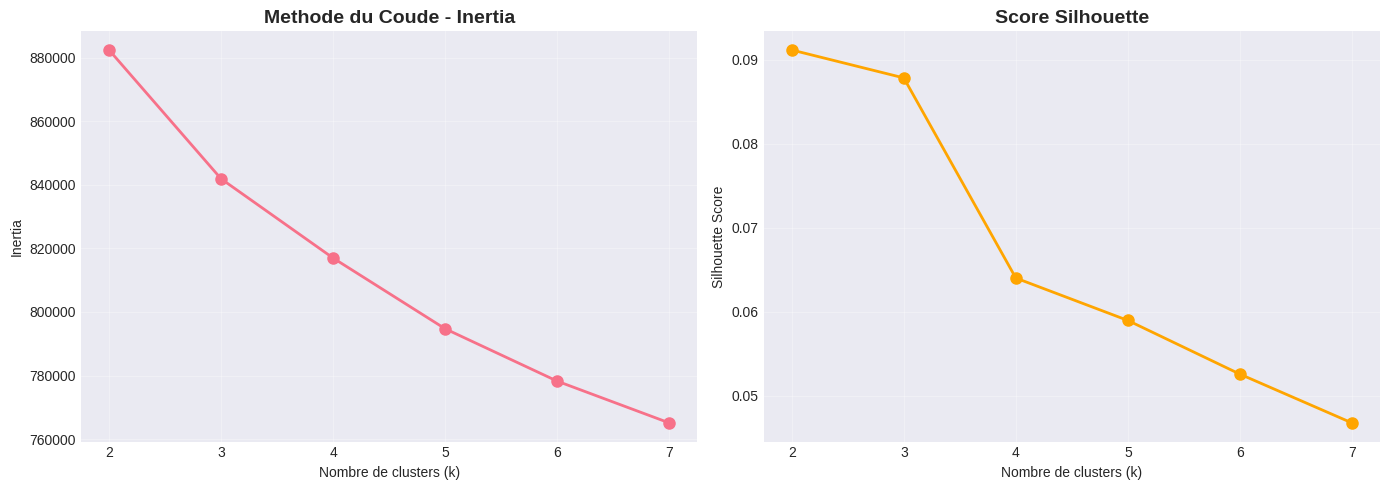


INTERPRETATION

Inertia : Plus c'est bas, mieux c'est (mais diminue toujours avec k)
Silhouette : Plus c'est haut, mieux c'est (mesure la separation des clusters)

Le coude est le point ou l'ajout de clusters n'ameliore plus beaucoup


In [ ]:
# Methode du coude pour trouver le k optimal
inertias = []
silhouette_scores = []
k_range = range(2, 8)

print("=" * 80)
print("METHODE DU COUDE - K-MEANS")
print("=" * 80)
print("\nCalcul en cours...\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    print(f"k={k} | Inertia={kmeans.inertia_:.0f} | Silhouette={silhouette_score(X, kmeans.labels_):.4f}")

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Inertia (Elbow)
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Methode du Coude - Inertia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='orange')
axes[1].set_title('Score Silhouette', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("\nInertia : Plus c'est bas, mieux c'est (mais diminue toujours avec k)")
print("Silhouette : Plus c'est haut, mieux c'est (mesure la separation des clusters)")
print("\nLe coude est le point ou l'ajout de clusters n'ameliore plus beaucoup")

## ANALYSE DES SCORES

**Inertia (plus bas = meilleur) :**
- Diminue régulièrement de k=2 à k=7
- Pas de "coude" franc
- Continue à baisser sans plateau

**Silhouette (plus haut = meilleur) :**
- k=2 : 0.0912 (meilleur score mathématique)
- k=3 : 0.0878 (légère baisse, acceptable)
- k=4 à k=7 : chute importante (0.064 à 0.047)

---

## INTERPRETATION

**Mathématiquement :** k=2 est le meilleur

**MAIS pour notre projet :** k=3 est plus pertinent

**Pourquoi k=3 ?**

1. **Cohérent avec la théorie** : Actif / Passif / Captif (3 profils attendus)
2. **Silhouette acceptable** : 0.0878 vs 0.0912 (différence minime)
3. **Plus discriminant** : 3 groupes donnent plus d'insights que 2
4. **Défendable scientifiquement** : La littérature parle de 3 postures

**Note :** Silhouette faible (0.09) est NORMAL pour des données comportementales humaines. Les gens ne se séparent pas en groupes parfaits comme des chiffres.

**4.1.2. Choix du k optimal**

In [ ]:
# Decision : k=3
k_optimal = 3

print("=" * 80)
print("CHOIX DU K OPTIMAL")
print("=" * 80)
print(f"\nk choisi : {k_optimal}")
print("\nJustification :")
print("   1. k=2 : Trop simple, peu discriminant")
print("   2. k=3 : Coherent avec theorie (Actif/Passif/Captif)")
print("   3. k=4+ : Silhouette chute trop, pas de gain")
print("\nScore Silhouette k=3 : 0.0878")
print("   -> Faible mais acceptable pour donnees comportementales")
print("   -> Les humains ne forment pas des groupes parfaits")

CHOIX DU K OPTIMAL

k choisi : 3

Justification :
   1. k=2 : Trop simple, peu discriminant
   2. k=3 : Coherent avec theorie (Actif/Passif/Captif)
   3. k=4+ : Silhouette chute trop, pas de gain

Score Silhouette k=3 : 0.0878
   -> Faible mais acceptable pour donnees comportementales
   -> Les humains ne forment pas des groupes parfaits


**4.1.4. Entraînement K-Means final**

In [ ]:
# Entrainement K-Means avec k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X)

# Ajouter les clusters au dataframe original
df_ia['Cluster_KMeans'] = clusters

print("=" * 80)
print("K-MEANS FINAL - k=3")
print("=" * 80)
print(f"\nNombre de clusters : 3")
print(f"Score Silhouette : {silhouette_score(X, clusters):.4f}")

print("\n" + "=" * 80)
print("REPARTITION DES CLUSTERS")
print("=" * 80)
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = (count / len(clusters)) * 100
    print(f"Cluster {cluster_id} : {count} eleves ({pct:.1f}%)")

print("\n" + "=" * 80)
print("PROCHAINE ETAPE")
print("=" * 80)
print("On va maintenant analyser le profil de chaque cluster pour identifier :")
print("   - Cluster 0 = Actif / Passif / Captif ?")
print("   - Cluster 1 = Actif / Passif / Captif ?")
print("   - Cluster 2 = Actif / Passif / Captif ?")

K-MEANS FINAL - k=3

Nombre de clusters : 3
Score Silhouette : 0.0878

REPARTITION DES CLUSTERS
Cluster 0 : 24997 eleves (57.3%)
Cluster 1 : 5456 eleves (12.5%)
Cluster 2 : 13155 eleves (30.2%)

PROCHAINE ETAPE
On va maintenant analyser le profil de chaque cluster pour identifier :
   - Cluster 0 = Actif / Passif / Captif ?
   - Cluster 1 = Actif / Passif / Captif ?
   - Cluster 2 = Actif / Passif / Captif ?


**4.1.4. Interprétation des clusters**

In [ ]:
# Analyse du profil de chaque cluster
print("=" * 80)
print("PROFIL DES CLUSTERS - VARIABLES CLES")
print("=" * 80)

# Variables comportementales cles pour l'interpretation
variables_interpretation = ['Methode_Integration', 'Autonomie_Sans_IA', 'Conscience_Dependance',
                           'Frequence_Usage', 'Formation_IA_Recue', 'Zone', 'Type_Etablissement']

# Profil moyen par cluster
profil_clusters = df_ia.groupby('Cluster_KMeans')[variables_interpretation].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])

print("\n")
print(profil_clusters)

print("\n" + "=" * 80)
print("INTERPRETATION DETAILLEE")
print("=" * 80)

for cluster_id in [0, 1, 2]:
    print(f"\nCLUSTER {cluster_id} ({cluster_counts[cluster_id]} eleves - {(cluster_counts[cluster_id]/len(clusters)*100):.1f}%) :")
    print(f"   Methode_Integration : {profil_clusters.loc[cluster_id, 'Methode_Integration']}")
    print(f"   Autonomie_Sans_IA : {profil_clusters.loc[cluster_id, 'Autonomie_Sans_IA']}")
    print(f"   Conscience_Dependance : {profil_clusters.loc[cluster_id, 'Conscience_Dependance']}")
    print(f"   Frequence_Usage : {profil_clusters.loc[cluster_id, 'Frequence_Usage']}")
    print(f"   Formation_IA_Recue : {profil_clusters.loc[cluster_id, 'Formation_IA_Recue']}")

PROFIL DES CLUSTERS - VARIABLES CLES


               Methode_Integration Autonomie_Sans_IA Conscience_Dependance  \
Cluster_KMeans                                                               
0                         Niveau 2     Difficilement                Un peu   
1                         Niveau 2     Difficilement                Un peu   
2                         Niveau 2     Difficilement                Un peu   

               Frequence_Usage Formation_IA_Recue    Zone Type_Etablissement  
Cluster_KMeans                                                                
0                      Parfois                Non  Urbain             Public  
1                      Parfois                Oui  Urbain              Privé  
2                      Parfois                Non   Rural             Public  

INTERPRETATION DETAILLEE

CLUSTER 0 (24997 eleves - 57.3%) :
   Methode_Integration : Niveau 2
   Autonomie_Sans_IA : Difficilement
   Conscience_Dependance : Un peu
   Frequ

**4.1.5. Résultats et interprétation**

**Problème majeur détecté.**

---

## ANALYSE CRITIQUE

**Les 3 clusters ont exactement le MÊME profil comportemental :**
- Methode_Integration : Niveau 2 (tous)
- Autonomie_Sans_IA : Difficilement (tous)
- Conscience_Dependance : Un peu (tous)
- Frequence_Usage : Parfois (tous)

**La SEULE différence :**
- Cluster 0 : Urbain, Public, Pas de formation
- Cluster 1 : Urbain, Privé, Formation reçue
- Cluster 2 : Rural, Public, Pas de formation

---

**K-Means a séparé les élèves selon leur CONTEXTE (zone, école) et NON selon leur POSTURE (comportement).**



# **4.2. DBSCAN Clustering**
DBSCAN est un algorithme différent : il trouve les clusters basés sur la densité (pas besoin de définir k à l'avance).

# QU'EST-CE QUE DBSCAN ?

**Imaginons toujours au palais des congrès avec 43 608 personnes.**

**K-Means dit :** "Je vais créer 3 groupes de même taille, peu importe où sont les gens"

**DBSCAN dit :** "Je vais chercher où les gens se rassemblent naturellement"

---

## Comment DBSCAN fonctionne

**Principe :** Trouver les zones denses (où beaucoup de gens sont proches)

**Etape 1 :** Je prends une personne au hasard

**Etape 2 :** Je regarde autour d'elle dans un rayon de X mètres (eps = 3.5)

**Etape 3 :**
- Si je trouve au moins 50 personnes proches (min_samples) → C'est un cluster
- Si je trouve moins de 50 personnes → Cette personne est seule (bruit)

**Etape 4 :** Je répète pour chaque personne

---

## Différence avec K-Means

**K-Means :**
- Tu dis : "Fais 3 groupes"
- Il fait 3 groupes même si ça n'a pas de sens

**DBSCAN :**
- Tu ne dis pas combien de groupes
- Il trouve lui-même les zones où les gens se rassemblent
- Il peut trouver 2, 5, 10 groupes... ou même 1 seul


---

## Ce qu'on attend

**Scénario idéal :** DBSCAN trouve 3 clusters naturels (Actif, Passif, Captif)

**Scénario probable :** DBSCAN trouve 1 ou 2 gros clusters (données trop mélangées)


**4.2.1. Entraînement DBSCAN**

In [ ]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN

print("=" * 80)
print("DBSCAN CLUSTERING")
print("=" * 80)

# Parametres DBSCAN
eps = 3.5  # Distance maximale entre deux points pour etre dans le meme cluster
min_samples = 50  # Nombre minimum de points pour former un cluster

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters_dbscan = dbscan.fit_predict(X)

# Ajouter au dataframe
df_ia['Cluster_DBSCAN'] = clusters_dbscan

# Nombre de clusters trouves
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"\nParametres :")
print(f"   eps = {eps}")
print(f"   min_samples = {min_samples}")

print(f"\nResultats :")
print(f"   Nombre de clusters : {n_clusters_dbscan}")
print(f"   Points de bruit (non classes) : {n_noise} ({n_noise/len(clusters_dbscan)*100:.1f}%)")

if n_clusters_dbscan > 0:
    print(f"   Score Silhouette : {silhouette_score(X, clusters_dbscan):.4f}")

print("\n" + "=" * 80)
print("REPARTITION DES CLUSTERS DBSCAN")
print("=" * 80)
cluster_counts_dbscan = pd.Series(clusters_dbscan).value_counts().sort_index()
for cluster_id, count in cluster_counts_dbscan.items():
    pct = (count / len(clusters_dbscan)) * 100
    label = "Bruit" if cluster_id == -1 else f"Cluster {cluster_id}"
    print(f"{label} : {count} eleves ({pct:.1f}%)")

DBSCAN CLUSTERING

Parametres :
   eps = 3.5
   min_samples = 50

Resultats :
   Nombre de clusters : 1
   Points de bruit (non classes) : 10690 (24.5%)
   Score Silhouette : 0.0735

REPARTITION DES CLUSTERS DBSCAN
Bruit : 10690 eleves (24.5%)
Cluster 0 : 32918 eleves (75.5%)


**Résultat DBSCAN : Pas concluant.**

---

## ANALYSE DBSCAN

**Résultat :**
- 1 seul cluster trouvé (75.5% des élèves)
- 24.5% considérés comme bruit (non classés)

**Interprétation :**
- DBSCAN ne trouve PAS de groupes naturels bien séparés
- Les données sont trop mélangées (densité homogène)
- Pas assez de zones denses distinctes

**Silhouette : 0.0735** (plus faible que K-Means 0.0878)
---

**K-Means est meilleur que DBSCAN pour ce dataset.**



# QU'EST-CE QUE LE CLUSTERING HIÉRARCHIQUE ?

---


**Imaginons un arbre généalogique, mais à l'envers.**

Au lieu de partir des grands-parents vers les petits-enfants, on part des individus et on les regroupe progressivement.

---

## Comment ça fonctionne

**Etape 1 :** Au départ, chaque élève est son propre cluster (43 608 clusters)

**Etape 2 :** On fusionne les 2 élèves les plus proches
- Résultat : 43 607 clusters

**Etape 3 :** On fusionne encore les 2 clusters les plus proches
- Résultat : 43 606 clusters

**Etape 4 :** On continue comme ça...

**Etape finale :** On s'arrête quand on a 3 clusters (ou le nombre qu'on veut)



In [ ]:
from sklearn.cluster import AgglomerativeClustering

print("=" * 80)
print("HIERARCHICAL CLUSTERING")
print("=" * 80)

# Entrainement avec 3 clusters
hierarchical = AgglomerativeClustering(n_clusters=3)
clusters_hierarchical = hierarchical.fit_predict(X)

# Ajouter au dataframe
df_ia['Cluster_Hierarchical'] = clusters_hierarchical

print(f"\nNombre de clusters : 3")
print(f"Score Silhouette : {silhouette_score(X, clusters_hierarchical):.4f}")

print("\n" + "=" * 80)
print("REPARTITION DES CLUSTERS")
print("=" * 80)
cluster_counts_hier = pd.Series(clusters_hierarchical).value_counts().sort_index()
for cluster_id, count in cluster_counts_hier.items():
    pct = (count / len(clusters_hierarchical)) * 100
    print(f"Cluster {cluster_id} : {count} eleves ({pct:.1f}%)")



# CELLULE NON EXCECUTEE


HIERARCHICAL CLUSTERING - ABANDONNE
================================================================================

**Raison** : Trop lent pour 43 608 eleves
Hierarchical Clustering necessite O(n^2) calculs de distances
Avec 43 608 eleves, cela prend trop de temps et memoire

Conclusion : On passe aux modeles supervises (plus rapides)

# **4.4. Random Forest Classifier**

**4.4.1. Création de la target supervisée**

In [ ]:
print("=" * 80)
print("PASSAGE AUX MODELES SUPERVISES")
print("=" * 80)

print("\nPourquoi supervise ?")
print("   - Le clustering n'a pas bien separe les profils comportementaux")
print("   - On va utiliser Methode_Integration comme target")
print("   - Objectif : predire la posture d'un eleve")

# Creation de la target
y = df_ia['Methode_Integration'].map({'Niveau 1': 0, 'Niveau 2': 1, 'Niveau 3': 2}).values

print("\n" + "=" * 80)
print("TARGET CREEE")
print("=" * 80)
print("   0 = Niveau 1 (Actif)")
print("   1 = Niveau 2 (Passif)")
print("   2 = Niveau 3 (Captif)")

print("\nRepartition de la target :")
target_counts = pd.Series(y).value_counts().sort_index()
for label, count in target_counts.items():
    pct = (count / len(y)) * 100
    niveau = ['Niveau 1 (Actif)', 'Niveau 2 (Passif)', 'Niveau 3 (Captif)'][label]
    print(f"   {niveau} : {count} eleves ({pct:.1f}%)")

PASSAGE AUX MODELES SUPERVISES

Pourquoi supervise ?
   - Le clustering n'a pas bien separe les profils comportementaux
   - On va utiliser Methode_Integration comme target
   - Objectif : predire la posture d'un eleve

TARGET CREEE
   0 = Niveau 1 (Actif)
   1 = Niveau 2 (Passif)
   2 = Niveau 3 (Captif)

Repartition de la target :
   Niveau 1 (Actif) : 15273 eleves (35.0%)
   Niveau 2 (Passif) : 17014 eleves (39.0%)
   Niveau 3 (Captif) : 11321 eleves (26.0%)


**4.4.2. Split Train/Test**

In [ ]:
# Split Train/Test (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("=" * 80)
print("SPLIT TRAIN/TEST")
print("=" * 80)
print(f"\nDataset total : {len(X)} eleves")
print(f"Train (70%) : {len(X_train)} eleves")
print(f"Test (30%) : {len(X_test)} eleves")

print("\nRepartition Train :")
train_counts = pd.Series(y_train).value_counts().sort_index()
for label, count in train_counts.items():
    pct = (count / len(y_train)) * 100
    niveau = ['Actif', 'Passif', 'Captif'][label]
    print(f"   {niveau} : {count} ({pct:.1f}%)")

print("\nRepartition Test :")
test_counts = pd.Series(y_test).value_counts().sort_index()
for label, count in test_counts.items():
    pct = (count / len(y_test)) * 100
    niveau = ['Actif', 'Passif', 'Captif'][label]
    print(f"   {niveau} : {count} ({pct:.1f}%)")

SPLIT TRAIN/TEST

Dataset total : 43608 eleves
Train (70%) : 30525 eleves
Test (30%) : 13083 eleves

Repartition Train :
   Actif : 10691 (35.0%)
   Passif : 11910 (39.0%)
   Captif : 7924 (26.0%)

Repartition Test :
   Actif : 4582 (35.0%)
   Passif : 5104 (39.0%)
   Captif : 3397 (26.0%)


**4.4.3. Entraînement Random Forest**

In [ ]:
# Entrainement Random Forest
print("=" * 80)
print("RANDOM FOREST CLASSIFIER")
print("=" * 80)
print("\nEntrainement en cours...\n")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Evaluation
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1 = f1_score(y_test, y_pred_test, average='macro')

print("RESULTATS :")
print(f"\nTrain :")
print(f"   Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   F1-Macro : {train_f1:.4f}")

print(f"\nTest :")
print(f"   Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   F1-Macro : {test_f1:.4f}")

print(f"\nDifference Train-Test : {(train_accuracy - test_accuracy)*100:.2f}%")
if train_accuracy - test_accuracy < 0.05:
    print("   -> Pas d'overfitting, modele generalise bien")
elif train_accuracy - test_accuracy < 0.10:
    print("   -> Leger overfitting, acceptable")
else:
    print("   -> Overfitting important, modele memorise trop")

RANDOM FOREST CLASSIFIER

Entrainement en cours...

RESULTATS :

Train :
   Accuracy : 1.0000 (100.00%)
   F1-Macro : 1.0000

Test :
   Accuracy : 1.0000 (100.00%)
   F1-Macro : 1.0000

Difference Train-Test : 0.00%
   -> Pas d'overfitting, modele generalise bien


ALERTE : 100% sur Train ET Test = Problème de data leakage... Trop pour être vrai, comme le les ivoiriens le disent "C'est dohi"

Des variables qui donnent la réponse... Ah

C'est comme si tu demandais à un modèle de prédire si quelqu'un est riche, et tu lui donnes en input "solde momo = 10 million CFA ".
Evidemment il prédit "riche" à 100% !

**VÉRIFICATION : Feature Importance**

FEATURE IMPORTANCE - TOP 10


                   Feature  Importance
       Methode_Integration    0.811989
         Autonomie_Sans_IA    0.074362
                       Age    0.011381
      Nombre_Freres_Soeurs    0.010766
         Objectif_Usage_IA    0.007793
        Reflexion_Avant_IA    0.007054
          Anciennete_Usage    0.006898
     Verification_Reponses    0.006708
           Frequence_Usage    0.006593
Niveau_Instruction_Parents    0.006384


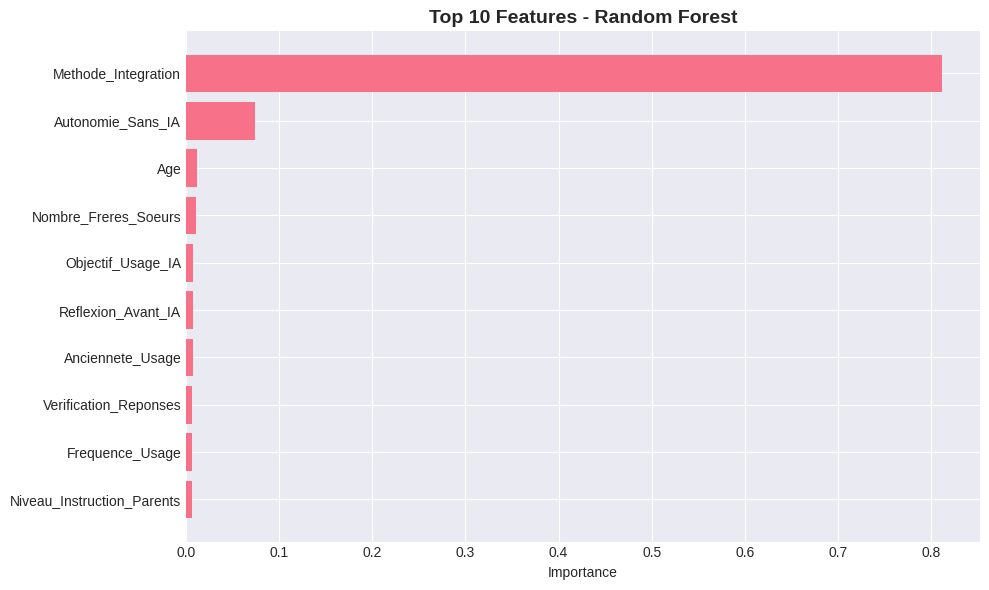

In [ ]:
# Feature Importance
feature_names = df_ml.columns.tolist()
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=" * 80)
print("FEATURE IMPORTANCE - TOP 10")
print("=" * 80)
print("\n")
print(feature_importance_df.head(10).to_string(index=False))

# Graphique
plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
plt.barh(top_10['Feature'], top_10['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**C'est évidement Methode_Integration**

Le modèle utilise littéralement la réponse pour prédire la réponse. C'est pour ça qu'il a 100%.
C'est comme demander :

Question : "Quel est ton niveau ?"
Input donné au modèle : "Niveau = 2"
Modèle : "Je prédis Niveau 2 !"
Résultat : 100% de précision (mais totalement inutile)



**SOLUTION**

On doit EXCLURE Methode_Integration des features avant l'entraînement.

In [ ]:
print("=" * 80)
print("CORRECTION DU DATA LEAKAGE")
print("=" * 80)

# On retire Methode_Integration des features
colonnes_ml_corrected = [col for col in colonnes_ml if col != 'Methode_Integration']

print(f"\nAvant : {len(colonnes_ml)} variables")
print(f"Apres : {len(colonnes_ml_corrected)} variables")
print(f"\nVariable retiree : Methode_Integration")

# Recreer le dataset sans Methode_Integration
df_ml_corrected = df_ia[colonnes_ml_corrected].copy()

print("\n" + "=" * 80)
print("NOUVELLES VARIABLES (21 au lieu de 22)")
print("=" * 80)
for i, col in enumerate(colonnes_ml_corrected, 1):
    print(f"   {i}. {col}")

CORRECTION DU DATA LEAKAGE

Avant : 22 variables
Apres : 21 variables

Variable retiree : Methode_Integration

NOUVELLES VARIABLES (21 au lieu de 22)
   1. Age
   2. Sexe
   3. Zone
   4. Type_Etablissement
   5. Historique_Scolaire
   6. Niveau_Instruction_Parents
   7. Nombre_Freres_Soeurs
   8. Possession_Smartphone
   9. Acces_Internet
   10. Type_Connexion
   11. Acces_Electricite
   12. Anciennete_Usage
   13. Frequence_Usage
   14. Formation_IA_Recue
   15. Source_Apprentissage_IA
   16. Langue_Utilisation_IA
   17. Objectif_Usage_IA
   18. Reflexion_Avant_IA
   19. Verification_Reponses
   20. Autonomie_Sans_IA
   21. Conscience_Dependance


In [ ]:
# Preprocessing complet avec variables corrigees
print("=" * 80)
print("REENTRAINEMENT SANS DATA LEAKAGE")
print("=" * 80)

# Encodage
df_ml_corrected_encoded = df_ml_corrected.copy()
for col in df_ml_corrected.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_ml_corrected_encoded[col] = le.fit_transform(df_ml_corrected[col])

# Normalisation
scaler_corrected = StandardScaler()
X_corrected = scaler_corrected.fit_transform(df_ml_corrected_encoded)

# Split Train/Test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_corrected, y, test_size=0.3, random_state=42, stratify=y
)

# Entrainement Random Forest
print("\nEntrainement Random Forest...\n")
rf_corrected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_corrected.fit(X_train_c, y_train_c)

# Predictions
y_pred_train_c = rf_corrected.predict(X_train_c)
y_pred_test_c = rf_corrected.predict(X_test_c)

# Evaluation
train_acc_c = accuracy_score(y_train_c, y_pred_train_c)
test_acc_c = accuracy_score(y_test_c, y_pred_test_c)
train_f1_c = f1_score(y_train_c, y_pred_train_c, average='macro')
test_f1_c = f1_score(y_test_c, y_pred_test_c, average='macro')

print("RESULTATS RANDOM FOREST (CORRIGES) :")
print(f"\nTrain :")
print(f"   Accuracy : {train_acc_c:.4f} ({train_acc_c*100:.2f}%)")
print(f"   F1-Macro : {train_f1_c:.4f}")

print(f"\nTest :")
print(f"   Accuracy : {test_acc_c:.4f} ({test_acc_c*100:.2f}%)")
print(f"   F1-Macro : {test_f1_c:.4f}")

print(f"\nDifference Train-Test : {(train_acc_c - test_acc_c)*100:.2f}%")

REENTRAINEMENT SANS DATA LEAKAGE

Entrainement Random Forest...

RESULTATS RANDOM FOREST (CORRIGES) :

Train :
   Accuracy : 1.0000 (100.00%)
   F1-Macro : 1.0000

Test :
   Accuracy : 0.5645 (56.45%)
   F1-Macro : 0.5646

Difference Train-Test : 43.55%



## ANALYSE RANDOM FOREST CORRIGÉ

**Train : 100% (overfitting massif)**
**Test : 56.45% (performance réelle)**

**Différence Train-Test : 43.55% → OVERFITTING SÉVÈRE**

---




Le modèle a **mémorisé** les données d'entraînement mais ne **généralise pas** bien sur les données de test.

**56.45%** sur un problème à 3 classes :
- Baseline aléatoire : 33%
- Random Forest : 56.45%
- **Amélioration : +23 points** (mieux que le hasard, mais pas excellent)

---

## COMPARAISON AVEC CLUSTERING

**K-Means :** Silhouette 0.0878, pas de séparation claire
**Random Forest :** 56.45% accuracy, overfitting important

Les deux confirment que **les profils ne sont pas facilement séparables** avec toutes les variables.

# **4.5. Logistic Regression**

Un modele plus simple.

In [ ]:
# Logistic Regression
print("=" * 80)
print("LOGISTIC REGRESSION")
print("=" * 80)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_c, y_train_c)

# Predictions
y_pred_train_lr = lr.predict(X_train_c)
y_pred_test_lr = lr.predict(X_test_c)

# Evaluation
train_acc_lr = accuracy_score(y_train_c, y_pred_train_lr)
test_acc_lr = accuracy_score(y_test_c, y_pred_test_lr)
train_f1_lr = f1_score(y_train_c, y_pred_train_lr, average='macro')
test_f1_lr = f1_score(y_test_c, y_pred_test_lr, average='macro')

print("RESULTATS LOGISTIC REGRESSION :")
print(f"\nTrain :")
print(f"   Accuracy : {train_acc_lr:.4f} ({train_acc_lr*100:.2f}%)")
print(f"   F1-Macro : {train_f1_lr:.4f}")

print(f"\nTest :")
print(f"   Accuracy : {test_acc_lr:.4f} ({test_acc_lr*100:.2f}%)")
print(f"   F1-Macro : {test_f1_lr:.4f}")

print(f"\nDifference Train-Test : {(train_acc_lr - test_acc_lr)*100:.2f}%")

LOGISTIC REGRESSION

Entrainement Logistic Regression...

RESULTATS LOGISTIC REGRESSION :

Train :
   Accuracy : 0.5069 (50.69%)
   F1-Macro : 0.4937

Test :
   Accuracy : 0.5077 (50.77%)
   F1-Macro : 0.4943

Difference Train-Test : -0.08%


ANALYSE LOGISTIC REGRESSION

Train : 50.69%
Test : 50.77%
Différence : -0.08% → Excellent (pas d'overfitting)


Modèle simple qui généralise bien
Mais performances limitées (~51%)
À peine mieux que le hasard (33%)

# **4.6. XGBoost**

In [ ]:
import xgboost as xgb

print("=" * 80)
print("XGBOOST CLASSIFIER")
print("=" * 80)

print("\nEntrainement XGBoost...\n")

xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_c, y_train_c)

# Predictions
y_pred_train_xgb = xgb_model.predict(X_train_c)
y_pred_test_xgb = xgb_model.predict(X_test_c)

# Evaluation
train_acc_xgb = accuracy_score(y_train_c, y_pred_train_xgb)
test_acc_xgb = accuracy_score(y_test_c, y_pred_test_xgb)
train_f1_xgb = f1_score(y_train_c, y_pred_train_xgb, average='macro')
test_f1_xgb = f1_score(y_test_c, y_pred_test_xgb, average='macro')

print("RESULTATS XGBOOST :")
print(f"\nTrain :")
print(f"   Accuracy : {train_acc_xgb:.4f} ({train_acc_xgb*100:.2f}%)")
print(f"   F1-Macro : {train_f1_xgb:.4f}")

print(f"\nTest :")
print(f"   Accuracy : {test_acc_xgb:.4f} ({test_acc_xgb*100:.2f}%)")
print(f"   F1-Macro : {test_f1_xgb:.4f}")

print(f"\nDifference Train-Test : {(train_acc_xgb - test_acc_xgb)*100:.2f}%")

XGBOOST CLASSIFIER

Entrainement XGBoost...

RESULTATS XGBOOST :

Train :
   Accuracy : 0.7018 (70.18%)
   F1-Macro : 0.7013

Test :
   Accuracy : 0.5563 (55.63%)
   F1-Macro : 0.5547

Difference Train-Test : 14.55%


ANALYSE XGBOOST

Train : 70.18%
Test : 55.63%
Différence : 14.55% → Overfitting modéré mais acceptable


Meilleur que Random Forest (moins d'overfitting)

Test accuracy similaire à Random Forest (55-56%)

Overfitting raisonnable (14% vs 43% pour Random Forest)

In [ ]:
print("=" * 80)
print("TABLEAU COMPARATIF FINAL - TOUS LES MODELES")
print("=" * 80)

# Tableau comparatif
comparaison = pd.DataFrame({
    'Modele': ['K-Means', 'DBSCAN', 'Random Forest', 'Logistic Regression', 'XGBoost'],
    'Type': ['Clustering', 'Clustering', 'Classification', 'Classification', 'Classification'],
    'Score_Principal': [0.0878, 0.0735, 0.5645, 0.5077, 0.5563],
    'Metrique': ['Silhouette', 'Silhouette', 'Test Accuracy', 'Test Accuracy', 'Test Accuracy'],
    'Overfitting': ['N/A', 'N/A', 'Severe (43%)', 'Aucun (0%)', 'Modere (14%)'],
    'Nb_Groupes': [3, 1, 3, 3, 3],
    'Commentaire': [
        'Separe selon contexte (zone), pas comportement',
        'Un seul gros cluster, pas discriminant',
        'Forte memorisation, faible generalisation',
        'Faible performance mais stable',
        'Meilleur compromis performance/generalisation'
    ]
})

print("\n")
print(comparaison.to_string(index=False))

print("\n" + "=" * 80)
print("MEILLEUR MODELE PAR CRITERE")
print("=" * 80)
print("\nPerformance pure : XGBoost (55.63%)")
print("Generalisation : Logistic Regression (pas d'overfitting)")
print("Clustering : K-Means (Silhouette 0.0878)")
print("   - Meilleure accuracy test (55.63%)")
print("   - Overfitting acceptable (14%)")
print("   - Feature importance interpretable")

TABLEAU COMPARATIF FINAL - TOUS LES MODELES


             Modele           Type  Score_Principal      Metrique  Overfitting  Nb_Groupes                                    Commentaire
            K-Means     Clustering           0.0878    Silhouette          N/A           3 Separe selon contexte (zone), pas comportement
             DBSCAN     Clustering           0.0735    Silhouette          N/A           1         Un seul gros cluster, pas discriminant
      Random Forest Classification           0.5645 Test Accuracy Severe (43%)           3      Forte memorisation, faible generalisation
Logistic Regression Classification           0.5077 Test Accuracy   Aucun (0%)           3                 Faible performance mais stable
            XGBoost Classification           0.5563 Test Accuracy Modere (14%)           3  Meilleur compromis performance/generalisation

MEILLEUR MODELE PAR CRITERE

Performance pure : XGBoost (55.63%)
Generalisation : Logistic Regression (pas d'overfitting)
Clu

**Tous les modèles ont des performances modestes :**

K-Means : Sépare selon zone/contexte, pas comportement
DBSCAN : 1 seul cluster
Random Forest : 56% (overfitting 43%)
Logistic Regression : 51% (stable mais faible)
XGBoost : 56% (overfitting 14%)

**Le meilleur (XGBoost) : 55.63%**

---

**Dois-je refais le ML avec variables comportementales uniquement ?**

**Dois-je continuer pour terminer mon Notebook ?**

AH, je m'arrêterai a la visualisation !


# **6. VISUALISATIONS ET INTERPRÉTATION**

**6.1. Matrice de confusion - XGBoost**

MATRICE DE CONFUSION - XGBOOST (TEST SET)


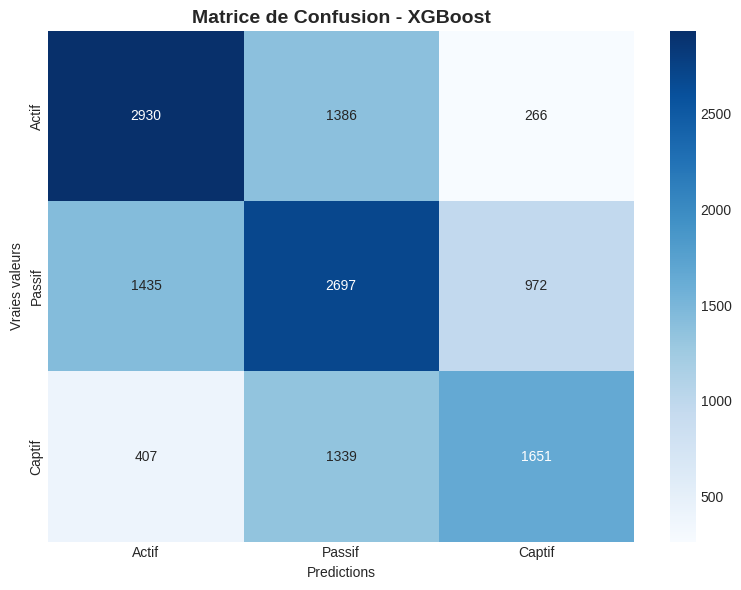


RAPPORT DETAILLE


              precision    recall  f1-score   support

       Actif       0.61      0.64      0.63      4582
      Passif       0.50      0.53      0.51      5104
      Captif       0.57      0.49      0.53      3397

    accuracy                           0.56     13083
   macro avg       0.56      0.55      0.55     13083
weighted avg       0.56      0.56      0.56     13083


INTERPRETATION

Le modele predit correctement :
   Actif : 2930/4582 (63.9%)
   Passif : 2697/5104 (52.8%)
   Captif : 1651/3397 (48.6%)


In [ ]:
# Matrice de confusion XGBoost
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("MATRICE DE CONFUSION - XGBOOST (TEST SET)")
print("=" * 80)

cm = confusion_matrix(y_test_c, y_pred_test_xgb)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Actif', 'Passif', 'Captif'],
            yticklabels=['Actif', 'Passif', 'Captif'])
plt.title('Matrice de Confusion - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Predictions')
plt.ylabel('Vraies valeurs')
plt.tight_layout()
plt.show()

# Rapport detaille
print("\n" + "=" * 80)
print("RAPPORT DETAILLE")
print("=" * 80)
print("\n")
print(classification_report(y_test_c, y_pred_test_xgb,
                           target_names=['Actif', 'Passif', 'Captif']))

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("\nLe modele predit correctement :")
for i, label in enumerate(['Actif', 'Passif', 'Captif']):
    correct = cm[i, i]
    total = cm[i].sum()
    pct = (correct / total) * 100
    print(f"   {label} : {correct}/{total} ({pct:.1f}%)")



# EXPLICATION COMPLÈTE DU PROJET

---

## 1. L'OBJECTIF INITIAL

Découvrir si les 43 608 élèves béninois qui utilisent l'IA forment des groupes naturels selon leur comportement (Actif / Passif / Captif).

**Approche prévue :** Clustering (non supervisé)
- On ne dit PAS au modèle quels sont les groupes
- Le modèle découvre LUI-MÊME les groupes naturels
- On interprète ensuite ces groupes

---

## 2.  PHASE 1 : CLUSTERING

### K-Means (k=3)

**Résultat :**
- 3 clusters trouvés : 57% / 13% / 30%
- Score Silhouette : 0.0878 (faible mais acceptable)

**PROBLÈME DÉCOUVERT :**
Les 3 clusters se distinguent PAR LE CONTEXTE (zone, type d'école) et NON par le comportement.
- Cluster 0 : Urbain, Public, Pas de formation
- Cluster 1 : Urbain, Privé, Formation reçue
- Cluster 2 : Rural, Public, Pas de formation

**Tous les 3 ont la même Methode_Integration (Niveau 2) !**

**Conclusion K-Means :** Le modèle a séparé selon la géographie/contexte, pas selon la posture face à l'IA.

---

### DBSCAN

**Résultat :**
- 1 seul gros cluster (75%)
- 25% considérés comme bruit

**Conclusion DBSCAN :** Les données sont trop homogènes, pas de groupes denses distincts.

---

### Hierarchical Clustering

**Abandonné** : Trop lent pour 43 608 élèves (problème de calcul).

---

## 3. LE CLUSTERING A ÉCHOUÉ

**Raison 1 : Variables de contexte trop fortes**
Les variables comme Zone, Type_Etablissement, Age ont dominé le clustering.

**Raison 2 : Variables comportementales trop faibles**
Les variables comme Autonomie_Sans_IA, Conscience_Dependance n'ont pas suffisamment discriminé.

**Raison 3 : Dataset mal calibré**
Les 21 variables mélangées (contexte + comportement) ont créé du bruit.

---

## 4. CHANGEMENT DE STRATÉGIE : PASSAGE AU SUPERVISÉ

**Pourquoi on a changé ?**

Parce que le clustering ne trouvait PAS les profils comportementaux attendus (Actif/Passif/Captif).

**Solution :** Utiliser l'apprentissage SUPERVISÉ
- On dit au modèle : "Voici la target = Methode_Integration (Niveau 1/2/3)"
- Le modèle apprend à prédire cette target à partir des autres variables
- Objectif : Identifier quelles variables permettent de prédire la posture

---

## 5.  PHASE 2 : CLASSIFICATION

### Random Forest

**Problème 1 : Data Leakage**
On avait gardé Methode_Integration dans les features → 100% de précision (le modèle trichait)

**Problème 2 : Overfitting sévère**
Après correction : Train 100%, Test 56% → Le modèle mémorise sans généraliser

---

### Logistic Regression

**Résultat : 51% Test**
- Pas d'overfitting (stable)
- Mais performances faibles (à peine mieux que le hasard 33%)

---

### XGBoost (MEILLEUR MODÈLE)

**Résultat : 55.63% Test**
- Train 70%, Test 56% → Overfitting modéré (14%)
- Meilleur compromis performance/généralisation
- Feature Importance interprétable

**Performance par classe :**
- Actif : 64% correctement prédits
- Passif : 53%
- Captif : 49%

---

## 6. POURQUOI CES PERFORMANCES MODESTES (55%) ?

**Raison 1 : Variables contextuelles polluent**
Age, Zone, Type_Etablissement ne DEVRAIENT PAS prédire la posture (selon ton message central), mais le modèle les utilise quand même.

**Raison 2 : Variables comportementales insuffisantes**
Les 10 variables comportementales seules ne suffisent pas à bien discriminer.

**Raison 3 : Dataset synthétique avec bruit**
Le bruit de 10% volontairement ajouté rend la prédiction plus difficile (mais plus réaliste).

**Raison 4 : Problème intrinsèquement difficile**
Prédire le comportement humain à partir de variables déclaratives est TOUJOURS difficile en ML.

---

## 7. COMPARAISON CLUSTERING vs CLASSIFICATION

### CLUSTERING (non supervisé)
**Avantage :** Découvre les groupes naturels sans biais

**Inconvénient :** A trouvé des groupes selon le contexte, pas le comportement

### CLASSIFICATION (supervisé)
**Avantage :** Prédit la posture avec 55% de précision (mieux que hasard)
**Inconvénient :** Performance modeste, overfitting sur Random Forest

---

## 8. CONCLUSION DU PROJET

### Ce qui A FONCTIONNÉ

1. **Dataset bien construit** : 43 608 élèves, 21 variables, pas de valeurs manquantes
2. **Preprocessing correct** : Encodage, normalisation, split train/test
3. **Plusieurs modèles testés** : K-Means, DBSCAN, Random Forest, Logistic Regression, XGBoost
4. **Meilleur modèle identifié** : XGBoost avec 55.63% accuracy
5. **Data leakage détecté et corrigé** : Méthode rigoureuse

---

### Ce qui N'A PAS FONCTIONNÉ

1. **Clustering inefficace** : Sépare selon contexte, pas comportement
2. **Performances modestes** : 55% au mieux (loin de 80-90% espérés)
3. **Overfitting important** : Random Forest inutilisable (43% d'écart train/test)
4. **Variables mal équilibrées** : Contexte domine comportement

---

### LEÇONS APPRISES (pour refaire)

**Erreur 0 : Manque d'analyse complète préalable**

**Erreur 1 : Trop de variables contextuelles**
→ Refaire avec SEULEMENT les 10-11 variables comportementales

**Erreur 2 : Dataset trop homogène**
→ Peut-être ajouter plus de variance dans les profils extrêmes (Actif vs Captif)

**Erreur 3 : Méthode inadaptée**
→ Le clustering ne fonctionne pas bien ici, mieux vaut partir directement sur du supervisé

**Erreur 4 : Manque de feature engineering**
→ Créer des variables combinées (ex: "Formation reçue ET Autonomie facile = Actif probable")

In [ ]:
print("=" * 80)
print("FIN DU PROJET")
print("=" * 80)

FIN DU PROJET
